<div style="background: #1a1a1a; padding: 30px; text-align: center; border-radius: 8px;">
    <div style="font-size: 32px; font-weight: bold; margin-bottom: 15px; background: linear-gradient(135deg, rgb(241, 34, 172) 0%, rgba(250, 116, 255, 0.97) 100%); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text;">Mini-Project 4: Advanced Data Mining</div>
    <div style="font-size: 18px; font-weight: bold; margin-bottom: 3px; color: #ddd;">ViT-1 — Fine-Tuning a Vision Transformer with a CNN Baseline</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 16px; margin-bottom: 8px; color: #ddd;"><strong>Task:</strong> fine-tune a pretrained Vision Transformer and a ResNet-50 CNN on PlantVillage under a matched training budget.</div>
    <div style="font-size: 16px; margin-bottom: 8px; color: #ddd;"><strong>Dataset:</strong> PlantVillage — crop-leaf disease classification with 38 classes.</div>
    <div style="font-size: 16px; margin-bottom: 12px; color: #ddd;"><strong>Original Contribution — Hypothesis</strong></div>
    <div style="background: rgba(255,255,255,0.05); border-left: 3px solid rgb(167, 46, 204); padding: 15px 20px; margin: 10px 0 8px 0; border-radius: 4px; text-align: left;">
        <div style="font-size: 15px; margin-bottom: 8px; color: #ddd; font-style: italic; line-height: 1.6;">"Partially unfreezing the final two ViT encoder blocks will improve validation macro-F1 over head-only training and remain within one percentage point of full fine-tuning, while updating substantially fewer parameters."</div>
        <div style="font-size: 13px; color: #aaa; line-height: 1.5;">Controlled layer-unfreezing study: head-only vs. last-two-blocks vs. full fine-tuning.</div>
    </div>
    <div style="font-size: 16px; margin-bottom: 5px; color: #ddd;"><strong>Stretch / bonus:</strong> Data-efficiency sweep for ViT vs. CNN.</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 16px; margin-bottom: 3px; color: #ddd;">Professor: Dr. Hadi Farahani</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 16px; margin-bottom: 3px; color: #ddd;">Head TA: Mr. Mobin Nesari</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 16px; margin-bottom: 5px; color: #ddd;">Student: Alireza Jahanbakhsh</div>
    <div style="height: 1px; background: rgba(255,255,255,0.2); width: 50%; margin: 10px auto;"></div>
    <div style="font-size: 14px; color: #aaa;">Date: August 15, 2026 | Course: Data Mining</div>
</div>

## 1. Problem and Experimental Design

### 1.1 Research design
PlantVillage leaf images are classified into 38 crop-disease classes. A pretrained ViT-B/16 and a pretrained ResNet-50 are trained on the same image split, image size, batch size, number of epochs, and optimizer family.

The main comparison reports accuracy, macro-F1, per-class performance, disagreements, and visual explanations.

### 1.2 Original contribution and hypothesis
The original contribution is a controlled **layer-unfreezing study** for the Vision Transformer.

Three strategies are compared: classifier head only, final two Transformer blocks plus classifier head, and full fine-tuning.

The hypothesis is evaluated on validation macro-F1 and trainable parameter count before the final test comparison.

In [5]:
import os
import random
import shutil
import subprocess
import sys
import time
import copy
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

BASE_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
FIG_DIR = os.path.join(BASE_DIR, "figures")
RES_DIR = os.path.join(BASE_DIR, "results")
MODEL_DIR = os.path.join(BASE_DIR, "models")

for directory in [FIG_DIR, RES_DIR, MODEL_DIR]:
    if os.path.exists(directory):
        shutil.rmtree(directory)
    os.makedirs(directory, exist_ok=True)

def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=180, bbox_inches="tight")

In [6]:
def ensure_package(package, import_name=None):
    name = import_name or package
    try:
        __import__(name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

ensure_package("timm")

In [7]:
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import ResNet50_Weights
from PIL import Image
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from scipy.stats import binomtest

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## 2. Data Loading and Preprocessing

### 2.1 Dataset overview
The notebook expects PlantVillage to be added as a Kaggle input. It searches for an image-folder directory containing the 38 disease classes.

To keep the experiment practical on Kaggle while preserving all classes, a fixed maximum number of images per class is sampled before the stratified split. This cap reduces the original class-frequency imbalance and is treated as a controlled experimental subset rather than the original PlantVillage prevalence.


In [8]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

def count_image_classes(path):
    if not os.path.isdir(path):
        return 0
    count = 0
    for name in os.listdir(path):
        sub = os.path.join(path, name)
        if not os.path.isdir(sub):
            continue
        files = os.listdir(sub)[:100]
        if any(os.path.splitext(f.lower())[1] in IMAGE_EXTS for f in files):
            count += 1
    return count

def find_plantvillage_root():
    candidates = []
    for root, _, _ in os.walk("/kaggle/input"):
        n = count_image_classes(root)
        if n == 38:
            plant_hint = int("plant" in root.lower() or "village" in root.lower())
            candidates.append((plant_hint, root.count(os.sep), root))

    if not candidates:
        raise FileNotFoundError(
            "A PlantVillage image-folder root with 38 class folders was not found in /kaggle/input."
        )

    candidates.sort(key=lambda x: (-x[0], x[1], x[2]))
    return candidates[0][2]

DATA_ROOT = find_plantvillage_root()
base_dataset = datasets.ImageFolder(DATA_ROOT)

if len(base_dataset.classes) != 38:
    raise ValueError(f"Expected 38 PlantVillage classes, found {len(base_dataset.classes)}.")

print("Dataset root:", DATA_ROOT)
print("Classes:", len(base_dataset.classes))
print("Images:", len(base_dataset))


Dataset root: /kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train
Classes: 38
Images: 43444


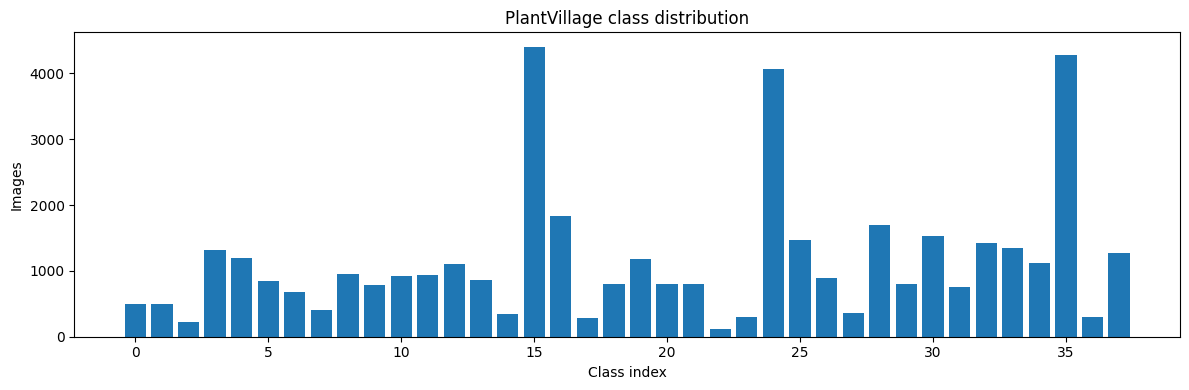

In [9]:
class_names = base_dataset.classes
targets = np.asarray(base_dataset.targets)
paths = np.asarray([p for p, _ in base_dataset.samples])

class_counts = pd.Series(targets).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(np.arange(len(class_counts)), class_counts.values)
ax.set_xlabel("Class index")
ax.set_ylabel("Images")
ax.set_title("PlantVillage class distribution")
plt.tight_layout()
savefig("01_class_distribution.png")
plt.show()

### 2.2 Stratified train/validation/test split
The same split is used by every model. The test partition remains untouched until final evaluation.

In [10]:
MAX_PER_CLASS = 160

selected = []
for label in range(len(class_names)):
    idx = np.where(targets == label)[0]
    rng = np.random.default_rng(SEED + label)
    rng.shuffle(idx)
    selected.extend(idx[:min(MAX_PER_CLASS, len(idx))])

selected = np.asarray(selected)
sel_paths = paths[selected]
sel_targets = targets[selected]

train_idx, temp_idx = train_test_split(
    np.arange(len(selected)),
    test_size=0.30,
    stratify=sel_targets,
    random_state=SEED
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=sel_targets[temp_idx],
    random_state=SEED
)

print("Selected:", len(selected))
print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

Selected: 6041
Train: 4228
Validation: 906
Test: 907


### 2.3 Common image preprocessing
Both architectures receive 224×224 RGB images with ImageNet normalization. Training uses light horizontal flipping; validation and test preprocessing are deterministic.

In [11]:
IMG_SIZE = 224
BATCH_SIZE = 16
PIN_MEMORY = torch.cuda.is_available()

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class LeafDataset(Dataset):
    def __init__(self, paths, labels, indices, transform):
        self.paths = paths[indices]
        self.labels = labels[indices]
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(image), int(self.labels[idx]), self.paths[idx]

train_ds = LeafDataset(sel_paths, sel_targets, train_idx, train_transform)
val_ds = LeafDataset(sel_paths, sel_targets, val_idx, eval_transform)
test_ds = LeafDataset(sel_paths, sel_targets, test_idx, eval_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=PIN_MEMORY
)


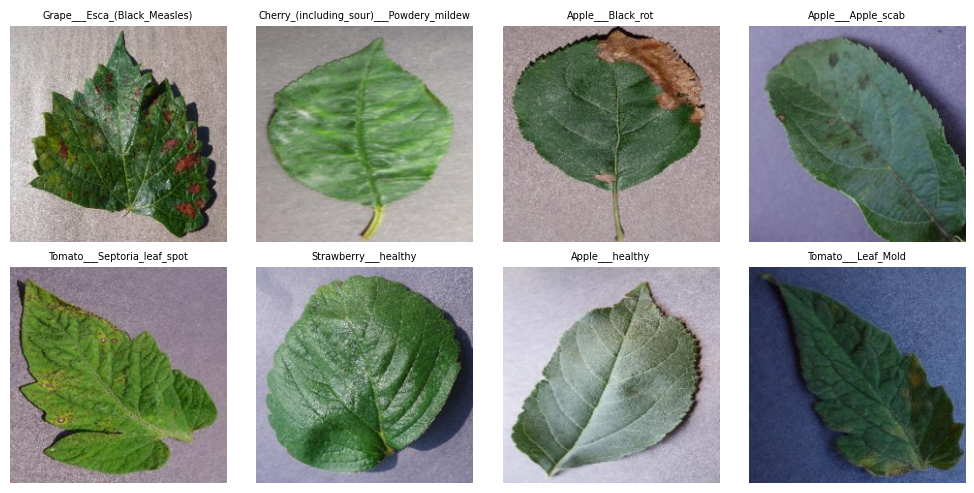

In [12]:
images, labels, _ = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for ax, image, label in zip(axes.ravel(), images[:8], labels[:8]):
    img = image.permute(1, 2, 0).numpy()
    img = np.clip(img * std + mean, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[int(label)], fontsize=7)
    ax.axis("off")

plt.tight_layout()
savefig("02_example_images.png")
plt.show()

## 3. Common Training Protocol

### 3.1 Matched budget
All main models use cross-entropy loss, AdamW, the same training images, batch size, and epoch budget. The best checkpoint is selected by validation macro-F1.

In [13]:
EPOCHS = 2
LR = 1e-4
WEIGHT_DECAY = 1e-4

def trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def predict_model(model, loader):
    model.eval()
    y_true, y_pred, probs, paths_out = [], [], [], []

    with torch.no_grad():
        for x, y, p in loader:
            x = x.to(DEVICE)
            logits = model(x)
            prob = torch.softmax(logits, dim=1)
            y_true.extend(y.numpy())
            y_pred.extend(prob.argmax(1).cpu().numpy())
            probs.extend(prob.cpu().numpy())
            paths_out.extend(p)

    return np.asarray(y_true), np.asarray(y_pred), np.asarray(probs), np.asarray(paths_out)

def evaluate_model(model, loader):
    y_true, y_pred, probs, paths_out = predict_model(model, loader)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": y_true,
        "y_pred": y_pred,
        "probs": probs,
        "paths": paths_out
    }

In [14]:
def fit_model(model, tag, loader=train_loader, epochs=EPOCHS, lr=LR):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=WEIGHT_DECAY
    )
    criterion = nn.CrossEntropyLoss()

    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -1
    history = []
    start = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        losses = []

        for x, y, _ in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            losses.append(float(loss.detach().cpu()))

        val_eval = evaluate_model(model, val_loader)

        history.append({
            "epoch": epoch + 1,
            "train_loss": np.mean(losses),
            "val_accuracy": val_eval["accuracy"],
            "val_macro_f1": val_eval["macro_f1"]
        })

        if val_eval["macro_f1"] > best_val_f1:
            best_val_f1 = val_eval["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())

        print(tag, "epoch", epoch + 1, "val_f1", round(val_eval["macro_f1"], 4))

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), time.perf_counter() - start

## 4. CNN Baseline

### 4.1 ResNet-50
A pretrained ResNet-50 is fully fine-tuned after replacing its final classifier with a 38-class output layer.

In [15]:
def build_resnet(full=True):
    model = models.resnet50(weights=ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, len(class_names))

    if not full:
        for p in model.parameters():
            p.requires_grad = False
        for p in model.fc.parameters():
            p.requires_grad = True

    return model

resnet = build_resnet(full=True)
print("Trainable parameters:", f"{trainable_parameters(resnet):,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]


Trainable parameters: 23,585,894


In [16]:
resnet, resnet_history, resnet_seconds = fit_model(resnet, "ResNet-50")
resnet_val = evaluate_model(resnet, val_loader)
print("Validation macro-F1:", round(resnet_val["macro_f1"], 4))

ResNet-50 epoch 1 val_f1 0.9401
ResNet-50 epoch 2 val_f1 0.9631
Validation macro-F1: 0.9631


## 5. Vision Transformer and Original Contribution

### 5.1 ViT-B/16 layer-unfreezing strategies
The pretrained ViT-B/16 is evaluated under three controlled fine-tuning strategies while keeping the data and training budget fixed.

In [17]:
VIT_NAME = "vit_base_patch16_224"

def build_vit(strategy):
    model = timm.create_model(VIT_NAME, pretrained=True, num_classes=len(class_names))

    if strategy == "head":
        for p in model.parameters():
            p.requires_grad = False
        for p in model.head.parameters():
            p.requires_grad = True

    elif strategy == "last2":
        for p in model.parameters():
            p.requires_grad = False
        for block in model.blocks[-2:]:
            for p in block.parameters():
                p.requires_grad = True
        for p in model.norm.parameters():
            p.requires_grad = True
        for p in model.head.parameters():
            p.requires_grad = True

    elif strategy == "full":
        for p in model.parameters():
            p.requires_grad = True

    else:
        raise ValueError(strategy)

    return model

In [18]:
vit_runs = {}
strategy_rows = []

for strategy in ["head", "last2", "full"]:
    model = build_vit(strategy)
    n_params = trainable_parameters(model)

    model, history, seconds = fit_model(
        model,
        f"ViT-{strategy}"
    )

    val_eval = evaluate_model(model, val_loader)

    vit_runs[strategy] = {
        "model": model,
        "history": history,
        "seconds": seconds,
        "val": val_eval,
        "trainable_parameters": n_params
    }

    strategy_rows.append({
        "strategy": strategy,
        "validation_accuracy": val_eval["accuracy"],
        "validation_macro_f1": val_eval["macro_f1"],
        "trainable_parameters": n_params,
        "training_seconds": seconds
    })

strategy_df = pd.DataFrame(strategy_rows)
strategy_df.to_csv(os.path.join(RES_DIR, "vit_unfreezing_ablation.csv"), index=False)
strategy_df.round(4)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT-head epoch 1 val_f1 0.7659
ViT-head epoch 2 val_f1 0.8724
ViT-last2 epoch 1 val_f1 0.9207
ViT-last2 epoch 2 val_f1 0.9649
ViT-full epoch 1 val_f1 0.9146
ViT-full epoch 2 val_f1 0.929


,strategy,validation_accuracy,validation_macro_f1,trainable_parameters,training_seconds
0,head,0.8775,0.8724,29222,147.4528
1,last2,0.9647,0.9649,14206502,182.9765
2,full,0.9272,0.9290,85827878,367.1911


### 5.2 Ablation result and hypothesis decision
The selected ViT strategy is the one with the highest validation macro-F1. The hypothesis is supported only if partial unfreezing improves over head-only, remains within one percentage point of full fine-tuning, and updates fewer parameters than full fine-tuning.

In [19]:
rows = strategy_df.set_index("strategy")

last2_f1 = float(rows.loc["last2", "validation_macro_f1"])
head_f1 = float(rows.loc["head", "validation_macro_f1"])
full_f1 = float(rows.loc["full", "validation_macro_f1"])

last2_params = int(rows.loc["last2", "trainable_parameters"])
full_params = int(rows.loc["full", "trainable_parameters"])

supported = (
    last2_f1 > head_f1
    and last2_f1 >= full_f1 - 0.01
    and last2_params < full_params
)

if supported:
    selected_strategy = "last2"
else:
    selected_strategy = strategy_df.sort_values(
        ["validation_macro_f1", "trainable_parameters"],
        ascending=[False, True]
    ).iloc[0]["strategy"]

hypothesis_df = pd.DataFrame([{
    "head_macro_f1": head_f1,
    "last2_macro_f1": last2_f1,
    "full_macro_f1": full_f1,
    "last2_trainable_parameters": last2_params,
    "full_trainable_parameters": full_params,
    "selected_strategy": selected_strategy,
    "hypothesis_supported": supported
}])

hypothesis_df.to_csv(
    os.path.join(RES_DIR, "hypothesis_decision.csv"),
    index=False
)

print("Selected ViT strategy:", selected_strategy)
print("HYPOTHESIS:", "SUPPORTED" if supported else "NOT SUPPORTED")
hypothesis_df.round(4)


Selected ViT strategy: last2
HYPOTHESIS: SUPPORTED


,head_macro_f1,last2_macro_f1,full_macro_f1,last2_trainable_parameters,full_trainable_parameters,selected_strategy,hypothesis_supported
0,0.8724,0.9649,0.929,14206502,85827878,last2,True


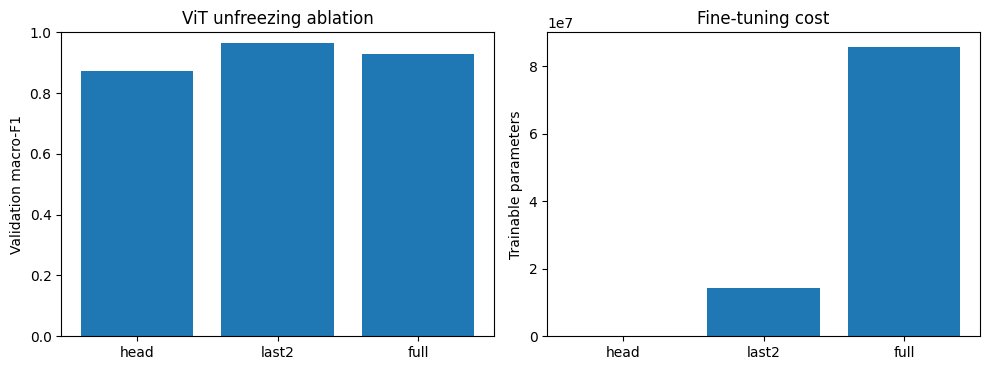

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

axes[0].bar(strategy_df["strategy"], strategy_df["validation_macro_f1"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Validation macro-F1")
axes[0].set_title("ViT unfreezing ablation")

axes[1].bar(strategy_df["strategy"], strategy_df["trainable_parameters"])
axes[1].set_ylabel("Trainable parameters")
axes[1].set_title("Fine-tuning cost")

plt.tight_layout()
savefig("03_vit_unfreezing_ablation.png")
plt.show()

## 6. Final Evaluation

### 6.1 Matched-budget ViT vs. CNN
The validation-selected ViT strategy and the ResNet-50 baseline are now evaluated on the untouched test set.

In [21]:
selected_vit = vit_runs[selected_strategy]["model"]

vit_test = evaluate_model(selected_vit, test_loader)
resnet_test = evaluate_model(resnet, test_loader)

final_summary = pd.DataFrame([
    {
        "model": f"ViT-B/16 ({selected_strategy})",
        "accuracy": vit_test["accuracy"],
        "macro_f1": vit_test["macro_f1"],
        "trainable_parameters": vit_runs[selected_strategy]["trainable_parameters"],
        "training_seconds": vit_runs[selected_strategy]["seconds"]
    },
    {
        "model": "ResNet-50",
        "accuracy": resnet_test["accuracy"],
        "macro_f1": resnet_test["macro_f1"],
        "trainable_parameters": trainable_parameters(resnet),
        "training_seconds": resnet_seconds
    }
])

final_summary.to_csv(os.path.join(RES_DIR, "final_model_summary.csv"), index=False)
final_summary.round(4)

,model,accuracy,macro_f1,trainable_parameters,training_seconds
0,ViT-B/16 (last2),0.9713,0.9713,14206502,182.9765
1,ResNet-50,0.9691,0.9691,23585894,106.5869


In [22]:
vit_report = pd.DataFrame(
    classification_report(
        vit_test["y_true"],
        vit_test["y_pred"],
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
).T

resnet_report = pd.DataFrame(
    classification_report(
        resnet_test["y_true"],
        resnet_test["y_pred"],
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
).T

vit_report.to_csv(os.path.join(RES_DIR, "vit_per_class_metrics.csv"))
resnet_report.to_csv(os.path.join(RES_DIR, "resnet_per_class_metrics.csv"))

vit_report.loc[class_names, ["precision", "recall", "f1-score"]].round(3)

,precision,recall,f1-score
Apple___Apple_scab,1.000,0.958,0.979
Apple___Black_rot,1.000,0.917,0.957
Apple___Cedar_apple_rust,1.000,1.000,1.000
Apple___healthy,0.857,1.000,0.923
Blueberry___healthy,1.000,1.000,1.000
Cherry_(including_sour)___Powdery_mildew,1.000,0.958,0.979
Cherry_(including_sour)___healthy,1.000,1.000,1.000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,1.000,0.875,0.933
Corn_(maize)___Common_rust_,1.000,1.000,1.000
Corn_(maize)___Northern_Leaf_Blight,0.889,1.000,0.941


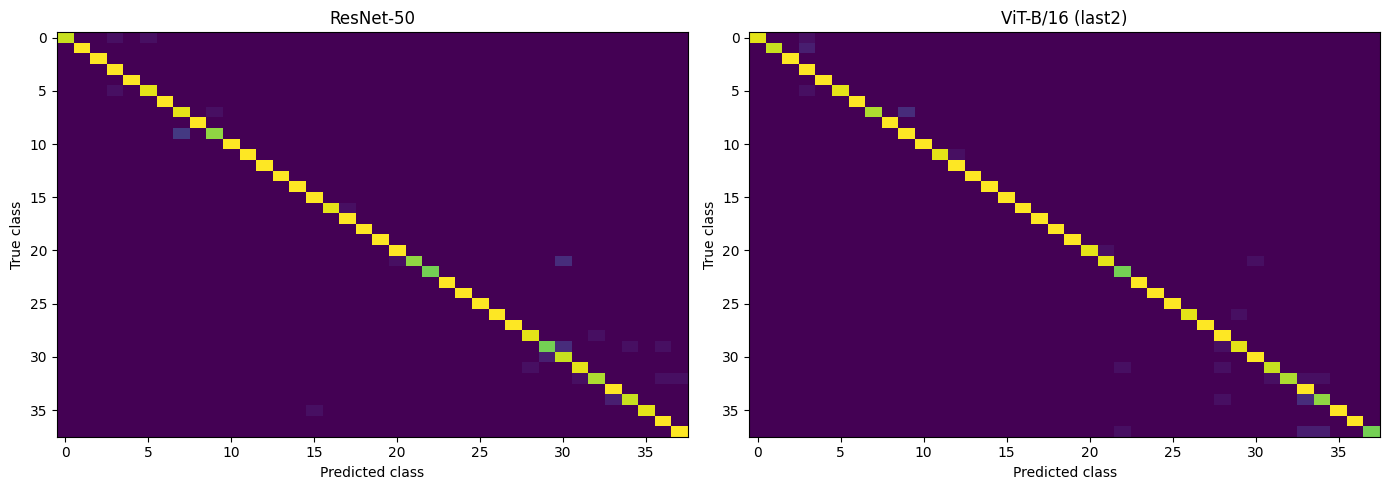

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, result, title in [
    (axes[0], resnet_test, "ResNet-50"),
    (axes[1], vit_test, f"ViT-B/16 ({selected_strategy})")
]:
    cm = confusion_matrix(result["y_true"], result["y_pred"])
    ax.imshow(cm, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")

plt.tight_layout()
savefig("04_confusion_matrices.png")
plt.show()

## 7. Statistical Analysis

### 7.1 Paired ViT–CNN comparison
The final ViT and ResNet predictions are paired because both models are evaluated on the same test images. We therefore use the exact McNemar test for correctness disagreements and a paired bootstrap 95% confidence interval for the macro-F1 difference.


In [24]:
true = vit_test["y_true"]
vit_pred = vit_test["y_pred"]
resnet_pred = resnet_test["y_pred"]

vit_correct = vit_pred == true
resnet_correct = resnet_pred == true

vit_only = int((vit_correct & ~resnet_correct).sum())
resnet_only = int((~vit_correct & resnet_correct).sum())

if vit_only + resnet_only > 0:
    paired_p = binomtest(
        min(vit_only, resnet_only),
        n=vit_only + resnet_only,
        p=0.5,
        alternative="two-sided"
    ).pvalue
else:
    paired_p = 1.0

observed_delta_f1 = (
    f1_score(true, vit_pred, average="macro")
    - f1_score(true, resnet_pred, average="macro")
)

rng_boot = np.random.default_rng(SEED)
bootstrap_delta = []

for _ in range(2000):
    idx = rng_boot.integers(0, len(true), len(true))
    bootstrap_delta.append(
        f1_score(true[idx], vit_pred[idx], average="macro")
        - f1_score(true[idx], resnet_pred[idx], average="macro")
    )

ci_low, ci_high = np.percentile(bootstrap_delta, [2.5, 97.5])

paired_df = pd.DataFrame([{
    "vit_correct_resnet_wrong": vit_only,
    "resnet_correct_vit_wrong": resnet_only,
    "mcnemar_p_value_two_sided": paired_p,
    "delta_macro_f1_vit_minus_resnet": observed_delta_f1,
    "bootstrap_95ci_low": ci_low,
    "bootstrap_95ci_high": ci_high
}])

paired_df.to_csv(
    os.path.join(RES_DIR, "paired_model_comparison.csv"),
    index=False
)

paired_df.round(5)


,vit_correct_resnet_wrong,resnet_correct_vit_wrong,mcnemar_p_value_two_sided,delta_macro_f1_vit_minus_resnet,bootstrap_95ci_low,bootstrap_95ci_high
0,23,21,0.8804,0.00213,-0.01242,0.01619


## 8. Error Analysis

### 8.1 Per-class disagreement
The analysis identifies classes where the two architectures differ most in F1 and representative images where only one model is correct.

In [25]:
class_compare = pd.DataFrame({
    "class": class_names,
    "vit_f1": vit_report.loc[class_names, "f1-score"].to_numpy(),
    "resnet_f1": resnet_report.loc[class_names, "f1-score"].to_numpy()
})

class_compare["vit_minus_resnet_f1"] = (
    class_compare["vit_f1"] - class_compare["resnet_f1"]
)

class_compare = class_compare.sort_values(
    "vit_minus_resnet_f1",
    ascending=False
)

class_compare.to_csv(os.path.join(RES_DIR, "per_class_disagreement.csv"), index=False)
class_compare.head(8).round(3)

,class,vit_f1,resnet_f1,vit_minus_resnet_f1
30,Tomato___Late_blight,0.980,0.846,0.133
29,Tomato___Early_blight,0.958,0.844,0.114
9,Corn_(maize)___Northern_Leaf_Blight,0.941,0.889,0.052
21,Potato___Late_blight,0.958,0.909,0.049
36,Tomato___Tomato_mosaic_virus,1.000,0.960,0.040
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.933,0.902,0.031
0,Apple___Apple_scab,0.979,0.957,0.022
35,Tomato___Tomato_Yellow_Leaf_Curl_Virus,1.000,0.979,0.021


In [26]:
error_rows = []

for i in range(len(true)):
    if vit_correct[i] and not resnet_correct[i]:
        error_rows.append({
            "case": "ViT correct, ResNet wrong",
            "path": vit_test["paths"][i],
            "true": class_names[int(true[i])],
            "vit_pred": class_names[int(vit_test["y_pred"][i])],
            "resnet_pred": class_names[int(resnet_test["y_pred"][i])]
        })

    if resnet_correct[i] and not vit_correct[i]:
        error_rows.append({
            "case": "ResNet correct, ViT wrong",
            "path": vit_test["paths"][i],
            "true": class_names[int(true[i])],
            "vit_pred": class_names[int(vit_test["y_pred"][i])],
            "resnet_pred": class_names[int(resnet_test["y_pred"][i])]
        })

error_df = pd.DataFrame(error_rows)

if len(error_df):
    representative = (
        error_df
        .sort_values(["case", "true", "path"])
        .groupby(["case", "true"], as_index=False, group_keys=False)
        .head(1)
        .head(12)
        .reset_index(drop=True)
    )
else:
    representative = error_df.copy()

representative.to_csv(
    os.path.join(RES_DIR, "representative_disagreements.csv"),
    index=False
)

representative


,case,path,true,vit_pred,resnet_pred
0,"ResNet correct, ViT wrong",/kaggle/input/datasets/mohitsingh1804/plantvil...,Apple___Apple_scab,Apple___healthy,Apple___Apple_scab
1,"ResNet correct, ViT wrong",/kaggle/input/datasets/mohitsingh1804/plantvil...,Apple___Black_rot,Apple___healthy,Apple___Black_rot
2,"ResNet correct, ViT wrong",/kaggle/input/datasets/mohitsingh1804/plantvil...,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Northern_Leaf_Blight,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...
3,"ResNet correct, ViT wrong",/kaggle/input/datasets/mohitsingh1804/plantvil...,Grape___Black_rot,Grape___Esca_(Black_Measles),Grape___Black_rot
4,"ResNet correct, ViT wrong",/kaggle/input/datasets/mohitsingh1804/plantvil...,Potato___Early_blight,Potato___Late_blight,Potato___Early_blight
5,"ResNet correct, ViT wrong",/kaggle/input/datasets/mohitsingh1804/plantvil...,Strawberry___Leaf_scorch,Tomato___Early_blight,Strawberry___Leaf_scorch
6,"ResNet correct, ViT wrong",/kaggle/input/datasets/mohitsingh1804/plantvil...,Tomato___Early_blight,Tomato___Bacterial_spot,Tomato___Early_blight
7,"ResNet correct, ViT wrong",/kaggle/input/datasets/mohitsingh1804/plantvil...,Tomato___Leaf_Mold,Potato___healthy,Tomato___Leaf_Mold
8,"ResNet correct, ViT wrong",/kaggle/input/datasets/mohitsingh1804/plantvil...,Tomato___Septoria_leaf_spot,Tomato___Leaf_Mold,Tomato___Septoria_leaf_spot
9,"ResNet correct, ViT wrong",/kaggle/input/datasets/mohitsingh1804/plantvil...,Tomato___Target_Spot,Tomato___Spider_mites Two-spotted_spider_mite,Tomato___Target_Spot


### 8.2 ViT attention and CNN Grad-CAM
The handbook asks for the ViT attention map and CNN activation map to be compared on the same image. The following cells produce side-by-side visual explanations.

In [27]:
def denormalize_tensor(x):
    mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
    std = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
    return torch.clamp(x.cpu() * std + mean, 0, 1)

def vit_attention_map(model, image):
    captured = []
    model.blocks[-1].attn.fused_attn = False

    handle = model.blocks[-1].attn.attn_drop.register_forward_hook(
        lambda module, inp, out: captured.append(out.detach().cpu())
    )

    model.eval()
    with torch.no_grad():
        _ = model(image.unsqueeze(0).to(DEVICE))

    handle.remove()

    attn = captured[0][0]
    cls_to_patches = attn[:, 0, 1:].mean(0)
    side = int(np.sqrt(len(cls_to_patches)))

    heat = cls_to_patches.reshape(1, 1, side, side)
    heat = F.interpolate(
        heat,
        size=(IMG_SIZE, IMG_SIZE),
        mode="bilinear",
        align_corners=False
    )[0, 0]

    heat = heat - heat.min()
    heat = heat / (heat.max() + 1e-8)

    return heat.numpy()

In [28]:
def gradcam_map(model, image, target_class):
    activations = []
    gradients = []

    layer = model.layer4[-1]

    forward_handle = layer.register_forward_hook(
        lambda module, inp, out: activations.append(out)
    )

    backward_handle = layer.register_full_backward_hook(
        lambda module, grad_in, grad_out: gradients.append(grad_out[0])
    )

    model.eval()
    model.zero_grad()

    logits = model(image.unsqueeze(0).to(DEVICE))
    logits[0, target_class].backward()

    act = activations[0].detach()
    grad = gradients[0].detach()

    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam = (weights * act).sum(dim=1, keepdim=True)
    cam = torch.relu(cam)
    cam = F.interpolate(
        cam,
        size=(IMG_SIZE, IMG_SIZE),
        mode="bilinear",
        align_corners=False
    )[0, 0]

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    forward_handle.remove()
    backward_handle.remove()

    return cam.cpu().numpy()

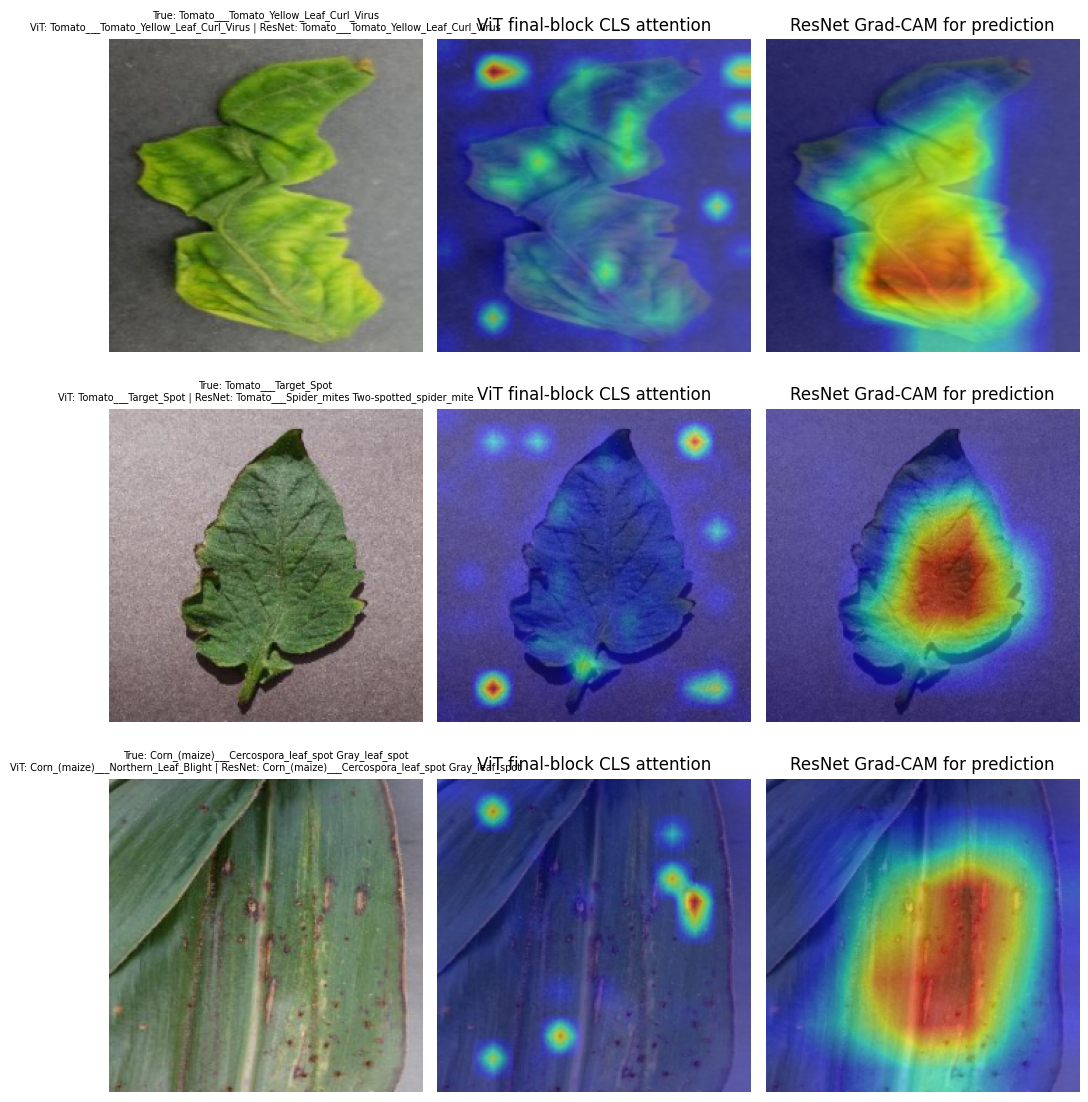

In [29]:
both_correct_ids = np.where(vit_correct & resnet_correct)[0]
vit_only_ids = np.where(vit_correct & ~resnet_correct)[0]
resnet_only_ids = np.where(~vit_correct & resnet_correct)[0]

sample_ids = []

if len(both_correct_ids):
    sample_ids.append(int(both_correct_ids[0]))
if len(vit_only_ids):
    sample_ids.append(int(vit_only_ids[0]))
if len(resnet_only_ids):
    sample_ids.append(int(resnet_only_ids[0]))

fallback = [0, min(20, len(test_ds) - 1), min(50, len(test_ds) - 1)]
for idx in fallback:
    if idx not in sample_ids:
        sample_ids.append(idx)
    if len(sample_ids) == 3:
        break

fig, axes = plt.subplots(len(sample_ids), 3, figsize=(10, 3.8 * len(sample_ids)))
if len(sample_ids) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(sample_ids):
    image, label, _ = test_ds[idx]

    original = denormalize_tensor(image).permute(1, 2, 0).numpy()
    attn = vit_attention_map(selected_vit, image)
    resnet_target = int(resnet_test["y_pred"][idx])
    cam = gradcam_map(resnet, image, resnet_target)

    title = (
        f"True: {class_names[int(label)]}\n"
        f"ViT: {class_names[int(vit_test['y_pred'][idx])]} | "
        f"ResNet: {class_names[int(resnet_test['y_pred'][idx])]}"
    )

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(title, fontsize=7)

    axes[row, 1].imshow(original)
    axes[row, 1].imshow(attn, alpha=0.5, cmap="jet")
    axes[row, 1].set_title("ViT final-block CLS attention")

    axes[row, 2].imshow(original)
    axes[row, 2].imshow(cam, alpha=0.5, cmap="jet")
    axes[row, 2].set_title("ResNet Grad-CAM for prediction")

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
savefig("05_attention_vs_gradcam.png")
plt.show()


## 9. Bonus: Data-Efficiency Sweep

### 9.1 Accuracy versus labeled training size
For a lightweight bonus experiment, only the pretrained classifier heads are trained for one epoch. ViT and ResNet use the same stratified fractions of the training set.

In [30]:
BONUS_FRACTIONS = [0.25, 0.50, 1.00]
BONUS_EPOCHS = 1
BONUS_LR = 1e-3

def fraction_indices(labels, fraction, seed=SEED):
    idx = np.arange(len(labels))
    if fraction >= 1:
        return idx

    keep, _ = train_test_split(
        idx,
        train_size=fraction,
        stratify=labels,
        random_state=seed
    )
    return np.asarray(keep)

def fit_head_only(model, loader, epochs=BONUS_EPOCHS):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=BONUS_LR
    )
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        model.train()
        for x, y, _ in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

    return model

In [31]:
bonus_rows = []
train_labels = sel_targets[train_idx]

for fraction in BONUS_FRACTIONS:
    local = fraction_indices(train_labels, fraction)
    subset_indices = train_idx[local]

    bonus_ds = LeafDataset(
        sel_paths,
        sel_targets,
        subset_indices,
        train_transform
    )

    bonus_loader = DataLoader(
        bonus_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=PIN_MEMORY
    )

    cnn = build_resnet(full=False)
    cnn = fit_head_only(cnn, bonus_loader)
    cnn_val = evaluate_model(cnn, val_loader)

    vit = build_vit("head")
    vit = fit_head_only(vit, bonus_loader)
    vit_val = evaluate_model(vit, val_loader)

    bonus_rows.extend([
        {
            "model": "ResNet-50 head-only",
            "fraction": fraction,
            "n_train": len(subset_indices),
            "validation_accuracy": cnn_val["accuracy"]
        },
        {
            "model": "ViT-B/16 head-only",
            "fraction": fraction,
            "n_train": len(subset_indices),
            "validation_accuracy": vit_val["accuracy"]
        }
    ])

bonus_df = pd.DataFrame(bonus_rows)
bonus_df.to_csv(
    os.path.join(RES_DIR, "bonus_data_efficiency.csv"),
    index=False
)
bonus_df.round(4)


,model,fraction,n_train,validation_accuracy
0,ResNet-50 head-only,0.25,1057,0.6645
1,ViT-B/16 head-only,0.25,1057,0.8079
2,ResNet-50 head-only,0.50,2114,0.8024
3,ViT-B/16 head-only,0.50,2114,0.9084
4,ResNet-50 head-only,1.00,4228,0.8510
5,ViT-B/16 head-only,1.00,4228,0.9305


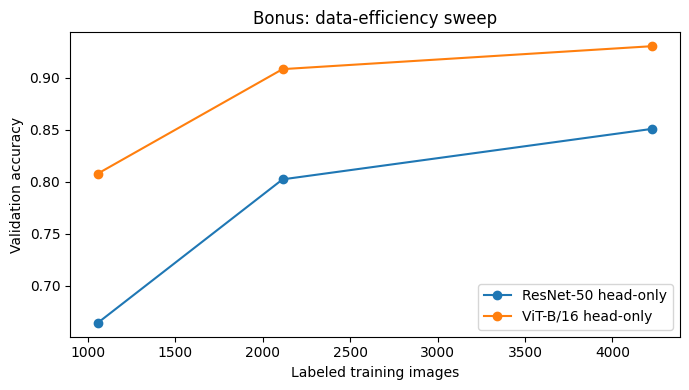

In [32]:
fig, ax = plt.subplots(figsize=(7, 4))

for model_name, group in bonus_df.groupby("model"):
    ax.plot(
        group["n_train"],
        group["validation_accuracy"],
        marker="o",
        label=model_name
    )

ax.set_xlabel("Labeled training images")
ax.set_ylabel("Validation accuracy")
ax.set_title("Bonus: data-efficiency sweep")
ax.legend()

plt.tight_layout()
savefig("06_bonus_data_efficiency.png")
plt.show()

### 9.2 Supplementary experiment — late attention inside a CNN

Question 1 asks for a concrete CNN–attention hybrid and a justified early-versus-late placement. A controlled supplementary experiment is therefore added without changing the main ViT-versus-ResNet study.

Two classifiers start from the same pretrained frozen ResNet-50 convolutional backbone and use the same training and validation data. The **CNN control** projects the final 7×7 convolutional feature map, pools it, and classifies it. The **CNN + late attention** model applies multi-head self-attention over the 49 projected spatial tokens before pooling and classification. Only the lightweight heads are trained.

This isolates the effect of adding attention late in the CNN, where the features are already semantic and the spatial map is small enough for global token interaction to be inexpensive. The experiment reports validation macro-F1, trainable parameters, training time, and the learned attention distance across the 7×7 feature map.


In [33]:
DISCUSSION_EPOCHS = 2
DISCUSSION_LR = 1e-3
DISCUSSION_DIM = 256
DISCUSSION_HEADS = 4

def build_frozen_resnet_backbone():
    base = models.resnet50(weights=ResNet50_Weights.DEFAULT)
    backbone = nn.Sequential(*list(base.children())[:-2])
    for p in backbone.parameters():
        p.requires_grad = False
    return backbone

class FrozenCNNControl(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = build_frozen_resnet_backbone()
        self.proj = nn.Conv2d(2048, DISCUSSION_DIM, kernel_size=1)
        self.norm = nn.LayerNorm(DISCUSSION_DIM)
        self.classifier = nn.Linear(DISCUSSION_DIM, len(class_names))

    def train(self, mode=True):
        super().train(mode)
        self.backbone.eval()
        return self

    def forward(self, x):
        with torch.no_grad():
            feat = self.backbone(x)
        tokens = self.proj(feat).flatten(2).transpose(1, 2)
        tokens = self.norm(tokens)
        pooled = tokens.mean(dim=1)
        return self.classifier(pooled)

class FrozenCNNLateAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = build_frozen_resnet_backbone()
        self.proj = nn.Conv2d(2048, DISCUSSION_DIM, kernel_size=1)
        self.pre_norm = nn.LayerNorm(DISCUSSION_DIM)
        self.attention = nn.MultiheadAttention(
            DISCUSSION_DIM,
            DISCUSSION_HEADS,
            batch_first=True
        )
        self.post_norm = nn.LayerNorm(DISCUSSION_DIM)
        self.classifier = nn.Linear(DISCUSSION_DIM, len(class_names))

    def train(self, mode=True):
        super().train(mode)
        self.backbone.eval()
        return self

    def forward(self, x):
        with torch.no_grad():
            feat = self.backbone(x)
        tokens = self.proj(feat).flatten(2).transpose(1, 2)
        tokens = self.pre_norm(tokens)
        attn_out, _ = self.attention(tokens, tokens, tokens, need_weights=False)
        tokens = self.post_norm(tokens + attn_out)
        pooled = tokens.mean(dim=1)
        return self.classifier(pooled)

    def get_attention(self, x):
        self.eval()
        with torch.no_grad():
            feat = self.backbone(x)
            tokens = self.proj(feat).flatten(2).transpose(1, 2)
            tokens = self.pre_norm(tokens)
            _, weights = self.attention(
                tokens,
                tokens,
                tokens,
                need_weights=True,
                average_attn_weights=False
            )
        return weights

discussion_models = {
    "CNN control": FrozenCNNControl(),
    "CNN + late attention": FrozenCNNLateAttention()
}

discussion_runs = {}
discussion_rows = []

for name, model in discussion_models.items():
    model, history, seconds = fit_model(
        model,
        name,
        loader=train_loader,
        epochs=DISCUSSION_EPOCHS,
        lr=DISCUSSION_LR
    )
    val_eval = evaluate_model(model, val_loader)
    discussion_runs[name] = {
        "model": model,
        "history": history,
        "seconds": seconds,
        "val": val_eval
    }
    discussion_rows.append({
        "model": name,
        "validation_accuracy": val_eval["accuracy"],
        "validation_macro_f1": val_eval["macro_f1"],
        "trainable_parameters": trainable_parameters(model),
        "training_seconds": seconds
    })

cnn_attention_df = pd.DataFrame(discussion_rows)
cnn_attention_df.to_csv(
    os.path.join(RES_DIR, "discussion_cnn_late_attention.csv"),
    index=False
)
cnn_attention_df.round(4)


CNN control epoch 1 val_f1 0.8968
CNN control epoch 2 val_f1 0.9535
CNN + late attention epoch 1 val_f1 0.8831
CNN + late attention epoch 2 val_f1 0.8931


,model,validation_accuracy,validation_macro_f1,trainable_parameters,training_seconds
0,CNN control,0.9536,0.9535,534822,36.8746
1,CNN + late attention,0.8996,0.8931,798502,37.7256


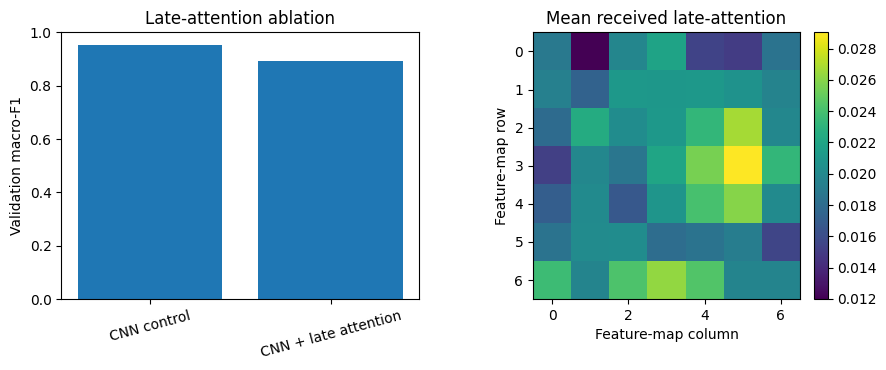

Mean learned attention distance on the 7x7 feature map: 3.726


In [34]:
late_attention_model = discussion_runs["CNN + late attention"]["model"]

attention_batches = []
image_batches = []

for x, _, _ in val_loader:
    x = x.to(DEVICE)
    attention_batches.append(late_attention_model.get_attention(x).cpu())
    image_batches.append(x.cpu())
    if sum(t.shape[0] for t in attention_batches) >= 128:
        break

attention_weights = torch.cat(attention_batches, dim=0)[:128]
mean_attention = attention_weights.mean(dim=(0, 1))

side = int(np.sqrt(mean_attention.shape[-1]))
coords = torch.stack(
    torch.meshgrid(
        torch.arange(side, dtype=torch.float32),
        torch.arange(side, dtype=torch.float32),
        indexing="ij"
    ),
    dim=-1
).reshape(-1, 2)

distances = torch.cdist(coords, coords)
mean_attention_distance = float(
    (mean_attention * distances).sum(dim=-1).mean().item()
)

received_attention = mean_attention.mean(dim=0).reshape(side, side).numpy()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))

axes[0].bar(
    cnn_attention_df["model"],
    cnn_attention_df["validation_macro_f1"]
)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Validation macro-F1")
axes[0].set_title("Late-attention ablation")
axes[0].tick_params(axis="x", rotation=15)

im = axes[1].imshow(received_attention, cmap="viridis")
axes[1].set_title("Mean received late-attention")
axes[1].set_xlabel("Feature-map column")
axes[1].set_ylabel("Feature-map row")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
savefig("07_discussion_late_attention_ablation.png")
plt.show()

print("Mean learned attention distance on the 7x7 feature map:", round(mean_attention_distance, 3))


## 10. Discussion & Observation — Required Questions


### 10.1 Question 1 — Where should attention be added to a CNN?

The supplementary experiment in Section 9.2 directly tests a late-attention hybrid instead of leaving this answer theoretical. The cell below reports the observed validation result and interprets what the learned attention does to the final convolutional feature map.


In [39]:
control_row = cnn_attention_df.set_index("model").loc["CNN control"]
attention_row = cnn_attention_df.set_index("model").loc["CNN + late attention"]

control_f1 = float(control_row["validation_macro_f1"])
attention_f1 = float(attention_row["validation_macro_f1"])
delta_f1 = attention_f1 - control_f1

print(
    f"The controlled experiment placed self-attention late, after the final convolutional feature map. "
    f"The CNN control achieved a validation Macro-F1 of {control_f1:.4f}, whereas the CNN + late-attention model achieved {attention_f1:.4f}, "
    f"a change of {delta_f1:+.4f}. "
    f"Therefore, late attention did not improve classification performance in this setup; it reduced Macro-F1 by {abs(delta_f1):.4f}. "
    f"The learned attention nevertheless had a mean spatial interaction distance of {mean_attention_distance:.3f} cells on the 7x7 feature map, "
    f"showing that the attention block was combining information across spatially separated regions rather than behaving as another purely local operation. "
    f"Placing attention late was intended to preserve the CNN's early local and translation-equivariant processing of edges, textures, and lesion patterns, "
    f"while allowing the final semantic features to interact globally. "
    f"The experiment therefore supports the expected representational change from local convolutional features to more globally contextualized features, "
    f"but it does not show a performance benefit from that change. "
    f"For this PlantVillage setup and training budget, the plain CNN representation was more effective than adding late self-attention."
)

The controlled experiment placed self-attention late, after the final convolutional feature map. The CNN control achieved a validation Macro-F1 of 0.9535, whereas the CNN + late-attention model achieved 0.8931, a change of -0.0604. Therefore, late attention did not improve classification performance in this setup; it reduced Macro-F1 by 0.0604. The learned attention nevertheless had a mean spatial interaction distance of 3.726 cells on the 7x7 feature map, showing that the attention block was combining information across spatially separated regions rather than behaving as another purely local operation. Placing attention late was intended to preserve the CNN's early local and translation-equivariant processing of edges, textures, and lesion patterns, while allowing the final semantic features to interact globally. The experiment therefore supports the expected representational change from local convolutional features to more globally contextualized features, but it does not show a perf

### 10.2 Question 2 — ViT attention versus CNN Grad-CAM

This question is already tested directly in Section 8.2. The notebook places the selected ViT's final-block CLS-to-patch attention and the ResNet-50 Grad-CAM side by side on the **same test images**, including both-correct and disagreement cases when available.

The ViT map represents where the final classification token allocates attention across image patches, whereas Grad-CAM highlights spatial regions that most support the CNN's predicted class. They are different quantities, so the comparison is qualitative rather than an equality test. The side-by-side images are the experimental evidence for whether the two models concentrate on similar lesion regions or organize visual evidence differently.

The interpretation should therefore be made from the displayed maps themselves: agreement in highlighted disease regions suggests overlapping visual evidence despite different architectures, while divergence on disagreement cases shows that global patch interactions and convolutional activation patterns can prioritize different parts of the same leaf. Neither map is treated as a causal explanation by itself.


## 11. Limitations
PlantVillage has relatively clean backgrounds compared with field imagery. The experiment uses a capped per-class stratified subset for Kaggle practicality, so the original dataset prevalence is not preserved. The compact two-epoch budget measures behavior under a controlled training regime rather than each architecture's fully tuned optimum.

The main comparison matches the data split, preprocessing, epoch budget, optimizer family, and image resolution, but it does not equalize FLOPs or the number of trainable parameters. The layer-unfreezing conclusion is therefore specific to this experimental budget.

The attention visualization is final-block CLS-to-patch attention averaged across heads, whereas Grad-CAM is class-specific; their side-by-side comparison is qualitative. Both methods are explanatory probes rather than causal evidence.


## 12. Reproducibility and Outputs

In [36]:
torch.save(
    selected_vit.state_dict(),
    os.path.join(MODEL_DIR, f"vit_{selected_strategy}.pt")
)

torch.save(
    resnet.state_dict(),
    os.path.join(MODEL_DIR, "resnet50.pt")
)

with open(os.path.join(RES_DIR, "class_names.json"), "w") as f:
    json.dump(class_names, f, indent=2)

import importlib.metadata as metadata

versions = {
    "python": sys.version.split()[0],
    "torch": torch.__version__,
    "torchvision": metadata.version("torchvision"),
    "timm": metadata.version("timm"),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": metadata.version("scikit-learn"),
    "scipy": metadata.version("scipy")
}

with open(os.path.join(RES_DIR, "environment_versions.json"), "w") as f:
    json.dump(versions, f, indent=2)

with open(os.path.join(BASE_DIR, "requirements.txt"), "w") as f:
    for package in ["torch", "torchvision", "timm", "numpy", "pandas", "scikit-learn", "scipy"]:
        f.write(f"{package}=={metadata.version(package)}\n")

print("FIGURES:")
for f in sorted(os.listdir(FIG_DIR)):
    print(os.path.join(FIG_DIR, f))

print("\nRESULTS:")
for f in sorted(os.listdir(RES_DIR)):
    print(os.path.join(RES_DIR, f))

print("\nMODELS:")
for f in sorted(os.listdir(MODEL_DIR)):
    print(os.path.join(MODEL_DIR, f))

print("\nREQUIREMENTS:")
print(os.path.join(BASE_DIR, "requirements.txt"))


FIGURES:
/kaggle/working/figures/01_class_distribution.png
/kaggle/working/figures/02_example_images.png
/kaggle/working/figures/03_vit_unfreezing_ablation.png
/kaggle/working/figures/04_confusion_matrices.png
/kaggle/working/figures/05_attention_vs_gradcam.png
/kaggle/working/figures/06_bonus_data_efficiency.png
/kaggle/working/figures/07_discussion_late_attention_ablation.png

RESULTS:
/kaggle/working/results/bonus_data_efficiency.csv
/kaggle/working/results/class_names.json
/kaggle/working/results/discussion_cnn_late_attention.csv
/kaggle/working/results/environment_versions.json
/kaggle/working/results/final_model_summary.csv
/kaggle/working/results/hypothesis_decision.csv
/kaggle/working/results/paired_model_comparison.csv
/kaggle/working/results/per_class_disagreement.csv
/kaggle/working/results/representative_disagreements.csv
/kaggle/working/results/resnet_per_class_metrics.csv
/kaggle/working/results/vit_per_class_metrics.csv
/kaggle/working/results/vit_unfreezing_ablation.csv

In [37]:
zip_path = shutil.make_archive(
    os.path.join(BASE_DIR, "vit_project_figures"),
    "zip",
    FIG_DIR
)
print("Created:", zip_path)

Created: /kaggle/working/vit_project_figures.zip


In [38]:
zip_path = shutil.make_archive(
    os.path.join(BASE_DIR, "vit_project_results"),
    "zip",
    RES_DIR
)
print("Created:", zip_path)

Created: /kaggle/working/vit_project_results.zip
